# Descripción de proyecto

Trabajas como analista de datos para la empresa de telecomunicaciones Megaline, la cual ofrece a sus clientes dos planes de prepago: Surf y Ultimate. El departamento comercial necesita identificar cuál de estos planes genera mayores ingresos, con el fin de optimizar la asignación del presupuesto de publicidad.

Para apoyar esta decisión, se realizará un análisis preliminar de las tarifas utilizando una muestra de clientes. El conjunto de datos incluye información de 500 usuarios de Megaline, como su ubicación, el plan que utilizan y sus patrones de consumo durante el año 2018, incluyendo la cantidad de llamadas realizadas, mensajes de texto enviados y uso de datos móviles.

Además de estimar los ingresos generados por cada plan, el análisis también se enfocará en comprender el comportamiento de los clientes, identificando patrones de uso y diferencias en el consumo entre los usuarios de cada tarifa.

El objetivo principal de este análisis es evaluar cómo se comportan los clientes según el plan contratado y determinar cuál de los planes de prepago genera mayores ingresos en promedio. Esta diferencia en ingresos será evaluada posteriormente mediante pruebas estadísticas.

# Descripción de las tarifas
Nota: Megaline redondea los segundos a minutos y los megabytes a gigabytes. Para las llamadas, cada llamada individual se redondea: incluso si la llamada duró solo un segundo, se contará como un minuto. Para el tráfico web, las sesiones web individuales no se redondean. En vez de esto, el total del mes se redondea hacia arriba. Si alguien usa 1025 megabytes este mes, se le cobrarán 2 gigabytes.

A continuación puedes ver una descripción de las tarifas:
    
Surf

Pago mensual: $20.00\
500 minutos al mes, 50 SMS y 15 GB de datos\
Si se exceden los límites del paquete:\
1 minuto: 3 centavos\
1 SMS: 3 centavos\
1 GB de datos: $10.\
Ultimate

Pago mensual: $70.\
3000 minutos al mes, 1000 SMS y 30 GB de datos.\
Si se exceden los límites del paquete:\
1 minuto: 1 centavo\
1 SMS: 1 centavo\
1 GB de datos: $7.00

### Análisis general de los datos
1- Obtener todas las bases de datos y librerías necesarias

2- Visualizar el tipo de datos que se van a manejar

3- Visualizar posibles duplicados 

4- Corregir datos

5- Enriquecer los datos

In [21]:
import pandas as pd
from scipy import stats as st
import numpy as np
import matplotlib.pyplot as plt
import math
# -----------------------------------------------------------------------#
meg_calls = pd.read_csv('datasets/megaline_calls.csv')
meg_internet = pd.read_csv('datasets/megaline_internet.csv')
meg_msm = pd.read_csv('datasets/megaline_messages.csv')
meg_plans = pd.read_csv('datasets/megaline_plans.csv')
meg_users = pd.read_csv('datasets/megaline_users.csv')

In [22]:
meg_calls.info()
meg_calls.sample(20)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 137735 entries, 0 to 137734
Data columns (total 4 columns):
 #   Column     Non-Null Count   Dtype  
---  ------     --------------   -----  
 0   id         137735 non-null  object 
 1   user_id    137735 non-null  int64  
 2   call_date  137735 non-null  object 
 3   duration   137735 non-null  float64
dtypes: float64(1), int64(1), object(2)
memory usage: 4.2+ MB


,id,user_id,call_date,duration
63092,1228_16,1228,2018-10-23,20.71
35624,1133_167,1133,2018-09-19,0.00
58106,1209_688,1209,2018-11-15,13.84
101654,1362_404,1362,2018-11-25,1.69
120531,1420_101,1420,2018-07-29,20.47
82500,1299_158,1299,2018-11-07,2.60
105830,1373_310,1373,2018-10-23,4.44
84001,1305_498,1305,2018-08-18,3.72
19058,1072_666,1072,2018-11-10,16.37
34696,1130_216,1130,2018-11-20,3.19


In [23]:
meg_internet.info()
meg_internet.sample(20)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 104825 entries, 0 to 104824
Data columns (total 4 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   id            104825 non-null  object 
 1   user_id       104825 non-null  int64  
 2   session_date  104825 non-null  object 
 3   mb_used       104825 non-null  float64
dtypes: float64(1), int64(1), object(2)
memory usage: 3.2+ MB


,id,user_id,session_date,mb_used
7844,1042_54,1042,2018-07-11,291.43
38209,1171_580,1171,2018-05-10,150.04
43712,1194_130,1194,2018-12-17,691.10
9473,1049_123,1049,2018-05-22,145.24
2408,1011_148,1011,2018-11-16,620.42
26849,1123_344,1123,2018-07-22,111.52
21284,1099_37,1099,2018-04-25,427.06
59869,1268_538,1268,2018-05-26,1081.56
28124,1128_278,1128,2018-09-11,60.35
67338,1313_12,1313,2018-11-16,849.41


In [24]:
meg_msm.info()
meg_msm.sample(20)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 76051 entries, 0 to 76050
Data columns (total 3 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   id            76051 non-null  object
 1   user_id       76051 non-null  int64 
 2   message_date  76051 non-null  object
dtypes: int64(1), object(2)
memory usage: 1.7+ MB


,id,user_id,message_date
59355,1374_529,1374,2018-10-05
25066,1148_53,1148,2018-12-10
56553,1357_205,1357,2018-09-18
71980,1467_312,1467,2018-10-17
31995,1199_111,1199,2018-10-13
38922,1254_671,1254,2018-08-12
2389,1028_301,1028,2018-12-12
46739,1318_145,1318,2018-11-19
31776,1196_262,1196,2018-04-29
2908,1030_7,1030,2018-12-15


In [25]:
meg_plans.info()
meg_plans.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2 entries, 0 to 1
Data columns (total 8 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   messages_included      2 non-null      int64  
 1   mb_per_month_included  2 non-null      int64  
 2   minutes_included       2 non-null      int64  
 3   usd_monthly_pay        2 non-null      int64  
 4   usd_per_gb             2 non-null      int64  
 5   usd_per_message        2 non-null      float64
 6   usd_per_minute         2 non-null      float64
 7   plan_name              2 non-null      object 
dtypes: float64(2), int64(5), object(1)
memory usage: 260.0+ bytes


,messages_included,mb_per_month_included,minutes_included,usd_monthly_pay,usd_per_gb,usd_per_message,usd_per_minute,plan_name
0,50,15360,500,20,10,0.03,0.03,surf
1,1000,30720,3000,70,7,0.01,0.01,ultimate


In [26]:
meg_users.info()
meg_users.sample(5)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   user_id     500 non-null    int64 
 1   first_name  500 non-null    object
 2   last_name   500 non-null    object
 3   age         500 non-null    int64 
 4   city        500 non-null    object
 5   reg_date    500 non-null    object
 6   plan        500 non-null    object
 7   churn_date  34 non-null     object
dtypes: int64(2), object(6)
memory usage: 31.4+ KB


,user_id,first_name,last_name,age,city,reg_date,plan,churn_date
176,1176,Terrance,Shaffer,75,"New York-Newark-Jersey City, NY-NJ-PA MSA",2018-10-03,surf,NaN
368,1368,Enola,Ray,60,"Pittsburgh, PA MSA",2018-05-20,ultimate,NaN
380,1380,Lajuana,Kelley,35,"San Jose-Sunnyvale-Santa Clara, CA MSA",2018-09-04,ultimate,NaN
359,1359,Sherley,Norris,33,"Colorado Springs, CO MSA",2018-02-08,surf,NaN
105,1105,Micheal,Poole,57,"Providence-Warwick, RI-MA MSA",2018-01-08,surf,NaN


Todos estos datasets tienen distintos propositos, como los 3 primeros que tiene informacion acerca del consumo de cada servicio proporcionado, no para internet, otro para mensajes y etc.
Uno con infomacion acerca de los usuarios y otro acerca de los datos de las tarifas que ofrece esta empresa.

Se puede ver que en todos los datasets el tipo de dato para las fechas es incorrecto.

En "churn date" hay información vacía, sin embargo en este caso se puede conservar este estado ya que indica que no se han cancelado las suscripciones.

En la base de datos meg_plans, los nombres de las columnas son demasiado largas, esto se puede reducir.

aqui se vio algo interesante y es que en varias ocaciones aparece el comsumo de internet en 0 o llamdas con duracion de 0, esto puede significar dos cosas que se estan tomando todos los dias sin excepcion o que se recopilo esta informacion por error

Además, en base a las condiciones de la suscripción se debe de redondear hacia arriba el internet consumido, así que esto se debe de corregir.

# Comprobacion de informacion

In [27]:
comprobacion = meg_internet.sort_values(
    by=['user_id', 'session_date'], ascending=True)
usuario = np.random.choice(meg_users['user_id'])
print(comprobacion[(comprobacion)['user_id'] == usuario])

             id  user_id session_date  mb_used
55603  1251_414     1251   2018-03-19  1109.83
55567  1251_378     1251   2018-03-20   672.82
55312  1251_123     1251   2018-03-21   647.22
55530  1251_341     1251   2018-03-21   607.29
55398  1251_209     1251   2018-03-22   880.72
...         ...      ...          ...      ...
55194    1251_5     1251   2018-12-27   232.54
55409  1251_220     1251   2018-12-29   240.38
55518  1251_329     1251   2018-12-30     0.00
55527  1251_338     1251   2018-12-30    89.57
55261   1251_72     1251   2018-12-31   163.30

[455 rows x 4 columns]


Aqui lo que se hizo es agarrar a un usuario al alzar y mostrar todo su historial de consumo, y demostro que incluso en un mismo dia hay registros con 0 de consumo lo cual se puede explicar si un usuario inicio sesion pero no descargo nada... pasara lo mismo con las llamadas?

In [28]:
comprobacion = meg_calls.sort_values(
    by=['user_id', 'call_date'], ascending=True)
usuario = np.random.choice(meg_users['user_id'])
print(comprobacion[(comprobacion)['user_id'] == usuario])

             id  user_id   call_date  duration
76970   1277_46     1277  2018-04-18     10.29
76940   1277_16     1277  2018-04-19      2.25
77048  1277_124     1277  2018-04-19      4.32
77221  1277_297     1277  2018-04-19     13.96
77629  1277_705     1277  2018-04-20     19.06
...         ...      ...         ...       ...
77581  1277_657     1277  2018-12-29      9.78
77133  1277_209     1277  2018-12-30      7.32
77217  1277_293     1277  2018-12-30     16.16
77618  1277_694     1277  2018-12-31      6.46
77720  1277_796     1277  2018-12-31      4.23

[846 rows x 4 columns]


Demuestra el mismo comportamiento teniendo como explicacion que el conteo de llamdas se cuenta desde el momento que contesta la otra persona, los registros en 0 puede significar que esta llamada no fue contestada.

Dado que nuestro objetivo de investigacion se centra principalmente en analizar el consumo realizadio y las ganancias generadas de cada plan esta informacion no es relevante, no se eliminara pero tampoco sera tomada en cuenta

asi que continuaremos a la correcion de los datos de los datasets presentados

# Correccion de errores en los datasets

In [29]:
# Cambio al tipo fecha de las columnas marcadas#

meg_users[['churn_date', 'reg_date']] = meg_users[[
    'churn_date', 'reg_date']].apply(pd.to_datetime)
meg_calls['call_date'] = pd.to_datetime(meg_calls['call_date'])
meg_internet['session_date'] = pd.to_datetime(meg_internet['session_date'])
meg_msm['message_date'] = pd.to_datetime(meg_msm['message_date'])


# Eliminar los datos duplicados#

meg_internet.drop_duplicates(inplace=True)
meg_calls.drop_duplicates(inplace=True)
meg_users.drop_duplicates(inplace=True)
meg_msm.drop_duplicates(inplace=True)

# Renombrar algunas columnas#

meg_plans = meg_plans.rename(columns={'plan_name': 'plan'})

In [30]:
meg_calls.info()
meg_calls.sample(20)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 137735 entries, 0 to 137734
Data columns (total 4 columns):
 #   Column     Non-Null Count   Dtype         
---  ------     --------------   -----         
 0   id         137735 non-null  object        
 1   user_id    137735 non-null  int64         
 2   call_date  137735 non-null  datetime64[ns]
 3   duration   137735 non-null  float64       
dtypes: datetime64[ns](1), float64(1), int64(1), object(1)
memory usage: 4.2+ MB


,id,user_id,call_date,duration
122943,1434_252,1434,2018-07-30,5.96
134420,1488_638,1488,2018-10-12,6.99
37501,1141_522,1141,2018-10-23,9.14
99522,1357_323,1357,2018-07-07,4.62
61303,1220_709,1220,2018-11-14,2.42
95441,1338_250,1338,2018-08-22,12.19
74197,1263_181,1263,2018-04-30,12.21
136623,1495_52,1495,2018-12-04,2.89
122969,1434_281,1434,2018-11-07,3.49
99962,1358_378,1358,2018-11-14,15.20


In [31]:
meg_internet.info()
meg_internet.sample(20)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 104825 entries, 0 to 104824
Data columns (total 4 columns):
 #   Column        Non-Null Count   Dtype         
---  ------        --------------   -----         
 0   id            104825 non-null  object        
 1   user_id       104825 non-null  int64         
 2   session_date  104825 non-null  datetime64[ns]
 3   mb_used       104825 non-null  float64       
dtypes: datetime64[ns](1), float64(1), int64(1), object(1)
memory usage: 3.2+ MB


,id,user_id,session_date,mb_used
71582,1334_150,1334,2018-04-16,312.38
40568,1182_256,1182,2018-12-10,24.27
79685,1372_32,1372,2018-12-31,677.34
32914,1148_9,1148,2018-12-22,366.17
21991,1100_195,1100,2018-12-31,567.16
86349,1400_486,1400,2018-10-03,0.00
45253,1201_113,1201,2018-07-18,347.09
30537,1140_80,1140,2018-09-15,126.50
72533,1337_17,1337,2018-12-15,823.01
74525,1351_11,1351,2018-12-15,0.00


In [32]:
meg_msm.info()
meg_msm.sample(20)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 76051 entries, 0 to 76050
Data columns (total 3 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   id            76051 non-null  object        
 1   user_id       76051 non-null  int64         
 2   message_date  76051 non-null  datetime64[ns]
dtypes: datetime64[ns](1), int64(1), object(1)
memory usage: 1.7+ MB


,id,user_id,message_date
49809,1328_767,1328,2018-11-04
50778,1330_379,1330,2018-12-31
67990,1439_384,1439,2018-10-25
1297,1011_260,1011,2018-11-20
45553,1312_37,1312,2018-05-04
66802,1434_350,1434,2018-12-18
41272,1264_443,1264,2018-10-13
27713,1172_170,1172,2018-08-23
70679,1460_165,1460,2018-09-24
15140,1101_197,1101,2018-09-12


In [33]:
meg_plans.info()
meg_plans.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2 entries, 0 to 1
Data columns (total 8 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   messages_included      2 non-null      int64  
 1   mb_per_month_included  2 non-null      int64  
 2   minutes_included       2 non-null      int64  
 3   usd_monthly_pay        2 non-null      int64  
 4   usd_per_gb             2 non-null      int64  
 5   usd_per_message        2 non-null      float64
 6   usd_per_minute         2 non-null      float64
 7   plan                   2 non-null      object 
dtypes: float64(2), int64(5), object(1)
memory usage: 260.0+ bytes


,messages_included,mb_per_month_included,minutes_included,usd_monthly_pay,usd_per_gb,usd_per_message,usd_per_minute,plan
0,50,15360,500,20,10,0.03,0.03,surf
1,1000,30720,3000,70,7,0.01,0.01,ultimate


In [34]:
meg_users.info()
meg_users.sample(5)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   user_id     500 non-null    int64         
 1   first_name  500 non-null    object        
 2   last_name   500 non-null    object        
 3   age         500 non-null    int64         
 4   city        500 non-null    object        
 5   reg_date    500 non-null    datetime64[ns]
 6   plan        500 non-null    object        
 7   churn_date  34 non-null     datetime64[ns]
dtypes: datetime64[ns](2), int64(2), object(4)
memory usage: 31.4+ KB


,user_id,first_name,last_name,age,city,reg_date,plan,churn_date
22,1022,Bo,Snow,73,"New York-Newark-Jersey City, NY-NJ-PA MSA",2018-04-20,surf,2018-09-07
469,1469,Rory,Nixon,75,"New York-Newark-Jersey City, NY-NJ-PA MSA",2018-06-04,surf,NaT
203,1203,Manie,Grimes,50,"Boston-Cambridge-Newton, MA-NH MSA",2018-02-11,surf,NaT
268,1268,Britni,Bowers,33,"Fresno, CA MSA",2018-01-13,surf,NaT
169,1169,Hai,Bean,67,"New York-Newark-Jersey City, NY-NJ-PA MSA",2018-12-06,surf,NaT


Con esto ademas de resolver las dudas de los valores en 0, tenemos los datsaets limpios por lo que podemos seguir con en analisis y en este caso con el enriquecimiento de datos ya que nos sera util.

# Enriquecimiento de datos

Se construirán datasets adicionales con el objetivo de organizar la información de manera más clara y facilitar el análisis, así como la generación de conclusiones sobre el comportamiento de los usuarios.

Para ello, se extrajo el componente mensual de las variables de fecha en los distintos datasets, con el fin de estandarizar la dimensión temporal y permitir una agregación consistente de la actividad por ciclo de facturación.

Asimismo, el límite de datos incluidos fue convertido de megabytes a gigabytes, aplicando redondeo hacia arriba (ceil). Esta transformación se realizó para alinearse con las reglas de facturación del negocio y garantizar precisión en el cálculo de ingresos y excedentes de consumo.

In [35]:
meg_msm["period"] = meg_msm["message_date"].dt.month
meg_calls["period"] = meg_calls["call_date"].dt.month
meg_users['month_reg'] = meg_users['reg_date'].dt.month
meg_users['month_churn'] = meg_users['churn_date'].dt.month
meg_internet["period"] = meg_internet["session_date"].dt.month
meg_plans['mb_per_month_included'] = np.ceil(
    meg_plans['mb_per_month_included'] / 1024)

Con las fechas modificadas podemos generar un nuevo dataset donde todas las tablas anteriores se unan en una tabla general

In [36]:
# Agregar los datos por usuario y por periodo de cada dataset#
llamadas_mes = meg_calls.groupby(['user_id', 'period']).size().reset_index()
min_llamadas = meg_calls.groupby(['user_id', 'period'])[
    'duration'].sum().reset_index()
n_mensajes = meg_msm.groupby(['user_id', 'period']).size().reset_index()
inter_trafic = meg_internet.groupby(['user_id', 'period'])[
    'mb_used'].sum().reset_index()

# Renombre de columnas#

llamadas_mes = llamadas_mes.rename(columns={0: 'calls_n'})
n_mensajes.rename(columns={0: 'n_msm'}, inplace=True)

# Creacion de un nuevo dataset
# #
total = pd.merge(llamadas_mes, min_llamadas, on=[
                 'user_id', 'period'], how='outer')
total = pd.merge(total, inter_trafic, on=['user_id', 'period'], how='outer')
total = pd.merge(total, n_mensajes, on=['user_id', 'period'], how='outer')
total = pd.merge(
    total, meg_users[['user_id', 'plan', 'city']], on='user_id', how='outer')
total = total.fillna(0)
total['mb_used'] = np.ceil(total['mb_used'] / 1024)
total['duration'] = np.ceil(total['duration'])
total.info()
total
total.to_excel('datasets/total.xlsx', index=False)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2303 entries, 0 to 2302
Data columns (total 8 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   user_id   2303 non-null   int64  
 1   period    2303 non-null   float64
 2   calls_n   2303 non-null   float64
 3   duration  2303 non-null   float64
 4   mb_used   2303 non-null   float64
 5   n_msm     2303 non-null   float64
 6   plan      2303 non-null   object 
 7   city      2303 non-null   object 
dtypes: float64(5), int64(1), object(2)
memory usage: 144.1+ KB


Con el dataset anterior se hará un nuevo dataset en donde se expondrán dos cosas: los límites que uno puede consumir por período y, al lado, lo que ha consumido extra en ese período. Teniendo como columna final lo que el usuario va a pagar en total, este total se calculará teniendo en cuenta la tarifa mencionada al inicio del proyecto y sumando lo extra por cada plan.

In [37]:
# Calculamos los excedentes
total_extra = total.merge(meg_plans, on='plan')
pares = [
    ('duration', 'minutes_included', 'minutos'),
    ('n_msm', 'messages_included', 'mensajes'),
    ('mb_used', 'mb_per_month_included', 'mb')
]
for usado, limite, prefijo in pares:
    total_extra[f'{prefijo}_dentro_plan'] = total_extra[[
        usado, limite]].min(axis=1)
    total_extra[f'{prefijo}_excedido'] = (
        total_extra[usado] - total_extra[limite]).clip(lower=0)
nuevo_orden = [
    'user_id', 'period', 'plan',
    'messages_included', 'mensajes_dentro_plan', 'mensajes_excedido',
    'mb_per_month_included', 'mb_dentro_plan', 'mb_excedido',
    'minutes_included', 'minutos_dentro_plan', 'minutos_excedido',
    'usd_monthly_pay', 'usd_per_gb', 'usd_per_message', 'usd_per_minute'
]
total_extra = total_extra[nuevo_orden]
total_extra['pago_total'] = (total_extra['usd_monthly_pay'] +
                             (total_extra['mb_excedido'] * total_extra['usd_per_gb']) +
                             (total_extra['mensajes_excedido'] * total_extra['usd_per_message']) +
                             (total_extra['minutos_excedido'] * total_extra['usd_per_minute']))
total_extra.info()
total_extra

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2303 entries, 0 to 2302
Data columns (total 17 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   user_id                2303 non-null   int64  
 1   period                 2303 non-null   float64
 2   plan                   2303 non-null   object 
 3   messages_included      2303 non-null   int64  
 4   mensajes_dentro_plan   2303 non-null   float64
 5   mensajes_excedido      2303 non-null   float64
 6   mb_per_month_included  2303 non-null   float64
 7   mb_dentro_plan         2303 non-null   float64
 8   mb_excedido            2303 non-null   float64
 9   minutes_included       2303 non-null   int64  
 10  minutos_dentro_plan    2303 non-null   float64
 11  minutos_excedido       2303 non-null   float64
 12  usd_monthly_pay        2303 non-null   int64  
 13  usd_per_gb             2303 non-null   int64  
 14  usd_per_message        2303 non-null   float64
 15  usd_

,user_id,period,plan,messages_included,mensajes_dentro_plan,mensajes_excedido,mb_per_month_included,mb_dentro_plan,mb_excedido,minutes_included,minutos_dentro_plan,minutos_excedido,usd_monthly_pay,usd_per_gb,usd_per_message,usd_per_minute,pago_total
0,1000,12.0,ultimate,1000,11.0,0.0,30.0,2.0,0.0,3000,117.0,0.0,70,7,0.01,0.01,70.00
1,1001,8.0,surf,50,30.0,0.0,15.0,7.0,0.0,500,172.0,0.0,20,10,0.03,0.03,20.00
2,1001,9.0,surf,50,44.0,0.0,15.0,14.0,0.0,500,298.0,0.0,20,10,0.03,0.03,20.00
3,1001,10.0,surf,50,50.0,3.0,15.0,15.0,7.0,500,375.0,0.0,20,10,0.03,0.03,90.09
4,1001,11.0,surf,50,36.0,0.0,15.0,15.0,4.0,500,405.0,0.0,20,10,0.03,0.03,60.00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2298,1498,12.0,surf,50,0.0,0.0,15.0,15.0,8.0,500,325.0,0.0,20,10,0.03,0.03,100.00
2299,1499,9.0,surf,50,0.0,0.0,15.0,13.0,0.0,500,331.0,0.0,20,10,0.03,0.03,20.00
2300,1499,10.0,surf,50,0.0,0.0,15.0,15.0,5.0,500,364.0,0.0,20,10,0.03,0.03,70.00
2301,1499,11.0,surf,50,0.0,0.0,15.0,15.0,2.0,500,289.0,0.0,20,10,0.03,0.03,40.00


Y a continuacion se agregara una nueva columna y la informacion que agregar sera la de entregar el pago total que va a efectuar un cliente en terminado periodo por mes

In [38]:
# calculamos los costos
def calcular_ingresos(df):
    # Calcular cargos por excedentes
    costo_minutos = df['minutos_excedido'] * df['usd_per_minute']
    costo_mensajes = df['mensajes_excedido'] * df['usd_per_message']
    costo_datos = df['mb_excedido'] * df['usd_per_gb']
    df['ingreso_mensual'] = df['usd_monthly_pay'] +\
        costo_minutos + costo_mensajes + costo_datos

    return df


df_s = calcular_ingresos(total_extra)
df_s
total = pd.merge(
    total,
    df_s[['user_id', 'period', 'ingreso_mensual']],
    on=['user_id', 'period'],
    how='outer'
)
total.info()
total

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2303 entries, 0 to 2302
Data columns (total 9 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   user_id          2303 non-null   int64  
 1   period           2303 non-null   float64
 2   calls_n          2303 non-null   float64
 3   duration         2303 non-null   float64
 4   mb_used          2303 non-null   float64
 5   n_msm            2303 non-null   float64
 6   plan             2303 non-null   object 
 7   city             2303 non-null   object 
 8   ingreso_mensual  2303 non-null   float64
dtypes: float64(6), int64(1), object(2)
memory usage: 162.1+ KB


,user_id,period,calls_n,duration,mb_used,n_msm,plan,city,ingreso_mensual
0,1000,12.0,16.0,117.0,2.0,11.0,ultimate,"Atlanta-Sandy Springs-Roswell, GA MSA",70.00
1,1001,8.0,27.0,172.0,7.0,30.0,surf,"Seattle-Tacoma-Bellevue, WA MSA",20.00
2,1001,9.0,49.0,298.0,14.0,44.0,surf,"Seattle-Tacoma-Bellevue, WA MSA",20.00
3,1001,10.0,65.0,375.0,22.0,53.0,surf,"Seattle-Tacoma-Bellevue, WA MSA",90.09
4,1001,11.0,64.0,405.0,19.0,36.0,surf,"Seattle-Tacoma-Bellevue, WA MSA",60.00
...,...,...,...,...,...,...,...,...,...
2298,1498,12.0,39.0,325.0,23.0,0.0,surf,"New York-Newark-Jersey City, NY-NJ-PA MSA",100.00
2299,1499,9.0,41.0,331.0,13.0,0.0,surf,"Orlando-Kissimmee-Sanford, FL MSA",20.00
2300,1499,10.0,53.0,364.0,20.0,0.0,surf,"Orlando-Kissimmee-Sanford, FL MSA",70.00
2301,1499,11.0,45.0,289.0,17.0,0.0,surf,"Orlando-Kissimmee-Sanford, FL MSA",40.00


# Estudio del comportamiendo de los clientes

En este apartado se harán varios cálculos a nivel estadístico para llegar a poder determinar la mayor ventaja económica y trazar gráficas para el análisis respectivo.

# Llamadas

c:\Users\meldo\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


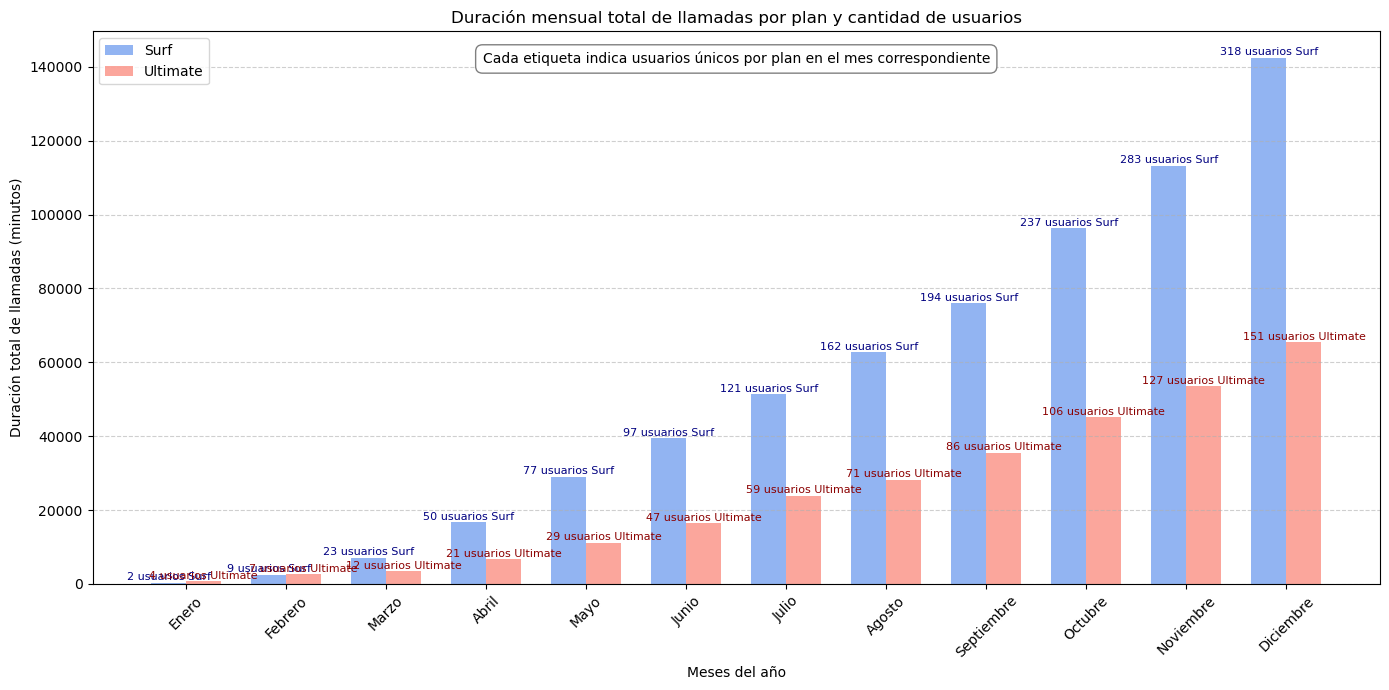

In [39]:
# Compara la duración promedio de llamadas por cada plan y por cada mes. Traza un gráfico de barras para visualizarla.
call_total = total.groupby(['period', 'plan'])[
    ['duration']].sum().reset_index()
usuarios_por_plan_mes = total.groupby(['period', 'plan'])[
    'user_id'].nunique().reset_index()
meses = list(range(1, 13))
nombres_meses = ['Enero', 'Febrero', 'Marzo', 'Abril', 'Mayo', 'Junio',
                 'Julio', 'Agosto', 'Septiembre', 'Octubre', 'Noviembre', 'Diciembre']
x = list(range(len(meses)))
ancho = 0.35
x_surf = [i - ancho/2 for i in x]
x_ultimate = [i + ancho/2 for i in x]
surf_call = call_total[call_total['plan'] == 'surf'].set_index(
    'period')['duration'].reindex(meses, fill_value=0)
ultimate_call = call_total[call_total['plan'] == 'ultimate'].set_index(
    'period')['duration'].reindex(meses, fill_value=0)
surf_users = usuarios_por_plan_mes[usuarios_por_plan_mes['plan'] == 'surf'].set_index(
    'period')['user_id'].reindex(meses, fill_value=0)
ultimate_users = usuarios_por_plan_mes[usuarios_por_plan_mes['plan'] == 'ultimate'].set_index(
    'period')['user_id'].reindex(meses, fill_value=0)
plt.figure(figsize=(14, 7))
bars_surf = plt.bar(x_surf, surf_call, ancho, label='Surf',
                    alpha=0.7, color='cornflowerblue')
bars_ultimate = plt.bar(x_ultimate, ultimate_call, ancho,
                        label='Ultimate', alpha=0.7, color='salmon')
for i, (bar_s, bar_u) in enumerate(zip(bars_surf, bars_ultimate)):
    plt.text(bar_s.get_x() + bar_s.get_width()/2, bar_s.get_height() + 100,
             f'{surf_users.iloc[i]} usuarios Surf', ha='center', va='bottom', fontsize=8, color='navy')
    plt.text(bar_u.get_x() + bar_u.get_width()/2, bar_u.get_height() + 100,
             f'{ultimate_users.iloc[i]} usuarios Ultimate', ha='center', va='bottom', fontsize=8, color='darkred')
plt.text(0.5, 0.95,
         'Cada etiqueta indica usuarios únicos por plan en el mes correspondiente',
         ha='center', va='center',
         transform=plt.gca().transAxes,
         fontsize=10,
         bbox=dict(facecolor='white', edgecolor='gray', boxstyle='round,pad=0.5'))

plt.xlabel('Meses del año')
plt.ylabel('Duración total de llamadas (minutos)')
plt.title('Duración mensual total de llamadas por plan y cantidad de usuarios')
plt.xticks(x, nombres_meses, rotation=45)
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

En esta grafica podemos ver que la mawyoria de los usuarios surf son los que mas tiempo pasan en llamada, lo cual es extraño porque el limite que otorga este plan es bajo, esto levanta una pregunta la cual es porque los usuarios prefieren excederse de los limites del surf en lugar de contratar el ultimate.

ademas de que se puede ver una creciente cantidad de usuarios a lo largo de los meses, por lo que se puede deducir que la popularidad de la empreza esta bien.

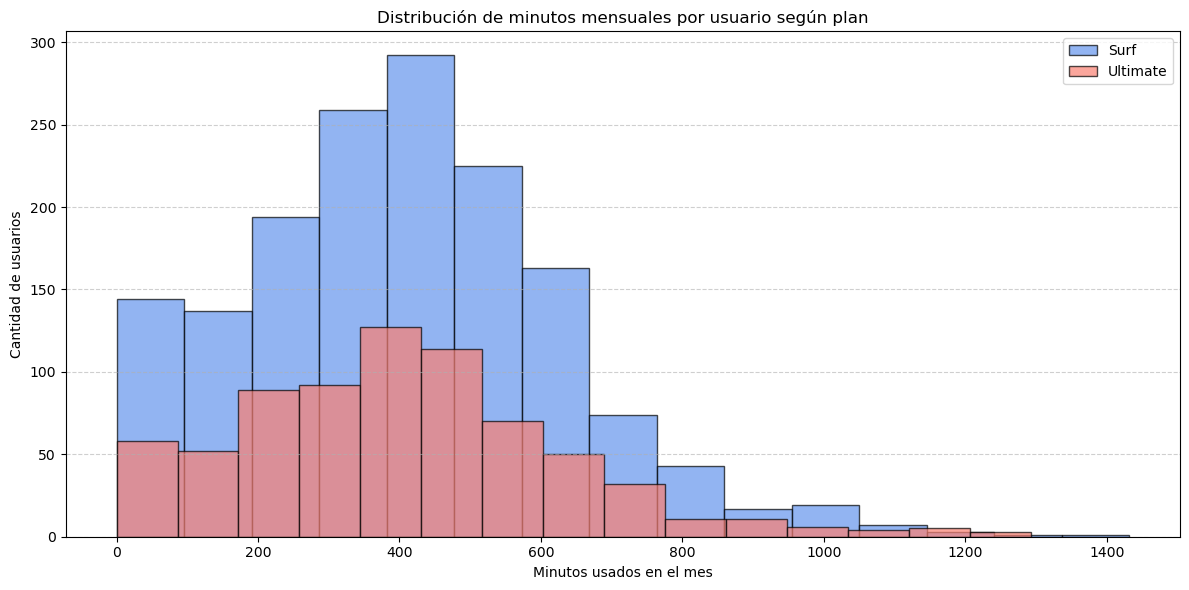

In [40]:

# Compara el número de minutos mensuales que necesitan los usuarios de cada plan. Traza un histograma.
duracion_por_usuario = total.groupby(['user_id', 'period', 'plan'])[
    'duration'].sum().reset_index()
surf_duracion = duracion_por_usuario[duracion_por_usuario['plan']
                                     == 'surf']['duration']
ultimate_duracion = duracion_por_usuario[duracion_por_usuario['plan']
                                         == 'ultimate']['duration']
plt.figure(figsize=(12, 6))
plt.hist(surf_duracion, bins=15, alpha=0.7, label='Surf',
         color='cornflowerblue', edgecolor='black')
plt.hist(ultimate_duracion, bins=15, alpha=0.7,
         label='Ultimate', color='salmon', edgecolor='black')

plt.title('Distribución de minutos mensuales por usuario según plan')
plt.xlabel('Minutos usados en el mes')
plt.ylabel('Cantidad de usuarios')
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

y con esta grafica se puede remarcar que el plan surf parece que tiene preferencia por parte de los usuarios demostrado por la candidad de usuarios usando este sistema tambien remarcando los promedios de duracion de las llamadas que es muy superior a lo consumido por los usuarios de ultimate, lo cual a simple vista quiere decir que hay algun problema con los precios, ya que ultimate ofrece una mayor cantidad de minutos para usar y sin embargo es superado por surf por mucho

In [41]:
# Calcula la media y la varianza de la duración mensual de llamadas.
llamadas = total.groupby(['plan', 'period'])[
    'duration'].sum().unstack(fill_value=0)
promedio_ultimate = llamadas.loc['ultimate'].mean()
var_u = llamadas.loc['ultimate'].var()
llamadas_s = llamadas.loc['surf'].mean()
var_s = llamadas.loc['surf'].var()
print(f'''Promedio de duracion para el plan Ultimate: {promedio_ultimate:.2f}
Promedio de duracion para el plan Surf: {llamadas_s:.2f}
Varianza de duracion para el plan Ultimate: {var_u:.2f}
Varianza de duracion para el plan Surf: {var_s:.2f}
''')

Promedio de duracion para el plan Ultimate: 22525.23
Promedio de duracion para el plan Surf: 49035.08
Varianza de duracion para el plan Ultimate: 472979378.19
Varianza de duracion para el plan Surf: 2185191321.24



Con lo anterior aqui se nota mucho mas ya que la diferencia es muy grande

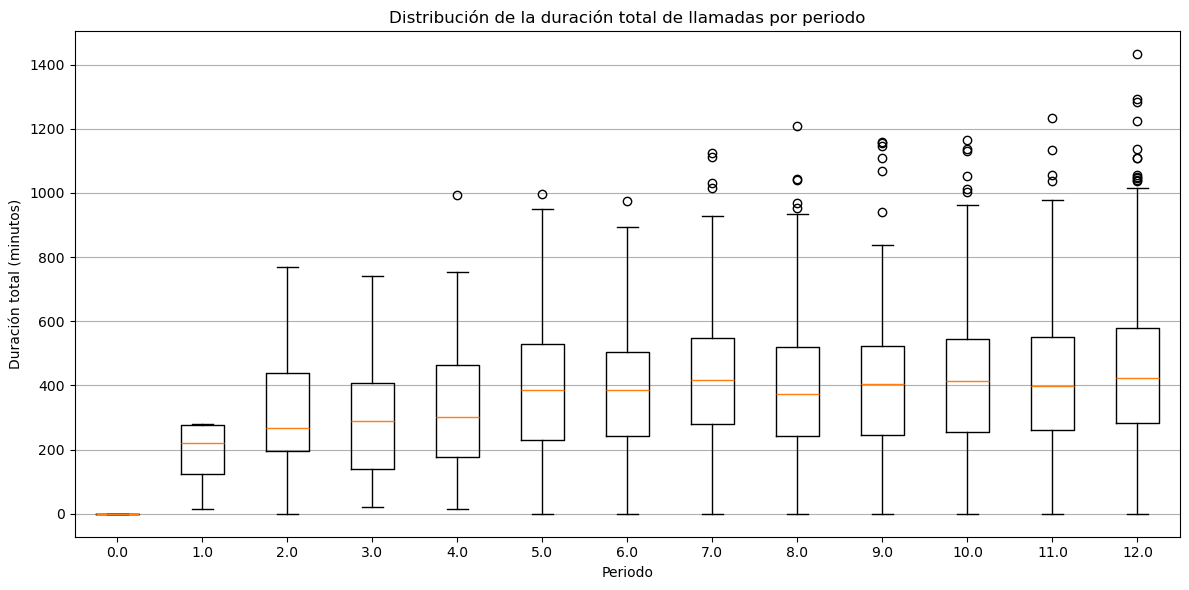

In [42]:
monthly_duration = (
    total
    .groupby(['period', 'user_id'])['duration']
    .sum()
    .reset_index()
)

# Crear datos para el boxplot por periodo
periods = sorted(monthly_duration['period'].unique())

data_by_period = [
    monthly_duration.loc[
        monthly_duration['period'] == p, 'duration'
    ]
    for p in periods
]

plt.figure(figsize=(12, 6))

plt.boxplot(data_by_period)

plt.title('Distribución de la duración total de llamadas por periodo')
plt.xlabel('Periodo')
plt.ylabel('Duración total (minutos)')

plt.xticks(range(1, len(periods) + 1), periods)

plt.grid(axis='y')

plt.tight_layout()
plt.show()

En esta grafica se observa un incremento progresivo en el consumo de minutos a lo largo de los periodos, reflejado en el aumento de la mediana y la dispersión de los datos. Esto indica que, con el tiempo, los usuarios tienden a utilizar más el servicio.

Asimismo, se identifican valores atípicos que representan usuarios con un consumo considerablemente alto. Sin embargo, los valores máximos observados (alrededor de 1480 minutos) se mantienen por debajo del límite del plan Ultimate (3000 minutos), lo que indica que incluso los usuarios más intensivos no alcanzan el consumo máximo permitido.

Las cajas muestran el rango donde se concentra la mayor parte del consumo evidenciando que el comportamiento de los usuarios se vuelve más variable conforme avanzan los periodos manteniendo una mediana del consumo en los periodos más avanzados que se sitúa alrededor de los 400 minutos, valor cercano al límite incluido en el plan Surf, lo que sugiere que una parte importante de los usuarios se mantiene dentro de este rango de consumo.

## conclusiones:
En el apartado de telefonia se puede ver que el plan ultimate esta ofreciendo mas de lo que el usuario realmente necesita, quitandole mucho atractivo y haciendo que los clientes se inclinen mas por el plan surf

# Mensajes

In [43]:
# Compara el número de mensajes que tienden a enviar cada mes los usuarios de cada plan
msm = total.groupby(['period', 'plan'])['n_msm'].sum().unstack(fill_value=0)
msm.sort_values(by='surf', ascending=False, inplace=True)
msm_u = msm['ultimate'].reindex(range(1, 13), fill_value=0)
msm_s = msm['surf'].reindex(range(1, 13), fill_value=0)

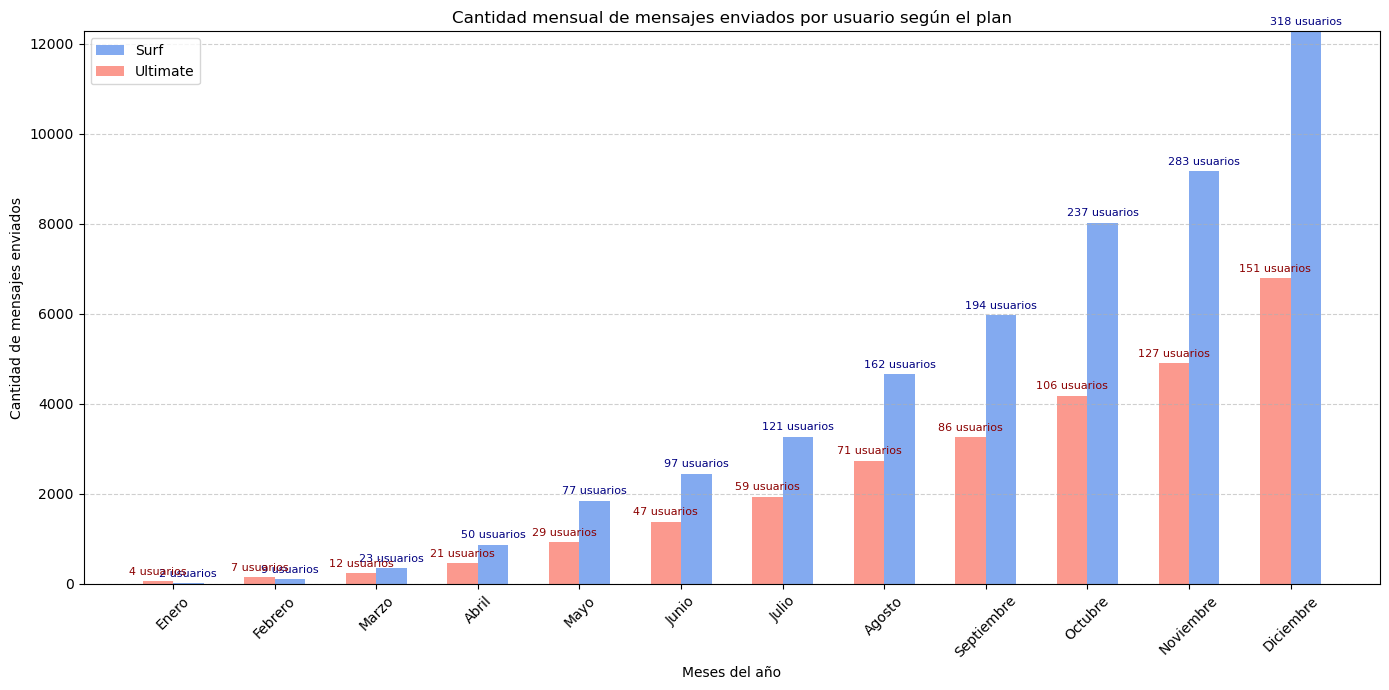

In [44]:
meses = list(range(1, 13))
nombres_meses = ['Enero', 'Febrero', 'Marzo', 'Abril', 'Mayo', 'Junio',
                 'Julio', 'Agosto', 'Septiembre', 'Octubre', 'Noviembre', 'Diciembre']
x = list(range(len(meses)))
ancho = 0.30
x_surf = [i + ancho / 2 for i in x]
x_ultimate = [i - ancho / 2 for i in x]
msm_s = msm_s.reindex(meses, fill_value=0)
msm_u = msm_u.reindex(meses, fill_value=0)
max_valor = max(msm_s.max(), msm_u.max())
limite_superior = math.ceil(max_valor)+1
plt.figure(figsize=(14, 7))
bars_surf = plt.bar(x_surf, msm_s, ancho, label='Surf',
                    alpha=0.8, color='cornflowerblue')
bars_ultimate = plt.bar(x_ultimate, msm_u, ancho,
                        label='Ultimate', alpha=0.8, color='salmon')
for i, (bar_s, bar_u) in enumerate(zip(bars_surf, bars_ultimate)):
    altura_s = bar_s.get_height()
    altura_u = bar_u.get_height()
    plt.text(bar_s.get_x() + bar_s.get_width()/2, altura_s + 100,
             f'{surf_users.iloc[i]} usuarios', ha='center', va='bottom', fontsize=8, color='navy')
    plt.text(bar_u.get_x() + bar_u.get_width()/2, altura_u + 100,
             f'{ultimate_users.iloc[i]} usuarios', ha='center', va='bottom', fontsize=8, color='darkred')
plt.title('Cantidad mensual de mensajes enviados por usuario según el plan')
plt.xlabel('Meses del año')
plt.ylabel('Cantidad de mensajes enviados')
plt.xticks(x, nombres_meses, rotation=45)
plt.ylim(0, limite_superior)
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()